In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import joblib
import string
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
print("imports are worked")

imports are worked


Shape: (6572, 2)


,label,text
0,spam,22 days to kick off! For Euro2004 U will be ke...
1,ham,Dai what this da.. Can i send my resume to thi...
2,ham,Al he does is moan at me if n e thin goes wron...
3,ham,Maanta waan mashquulsanahay.
4,ham,I'm in class. Will holla later


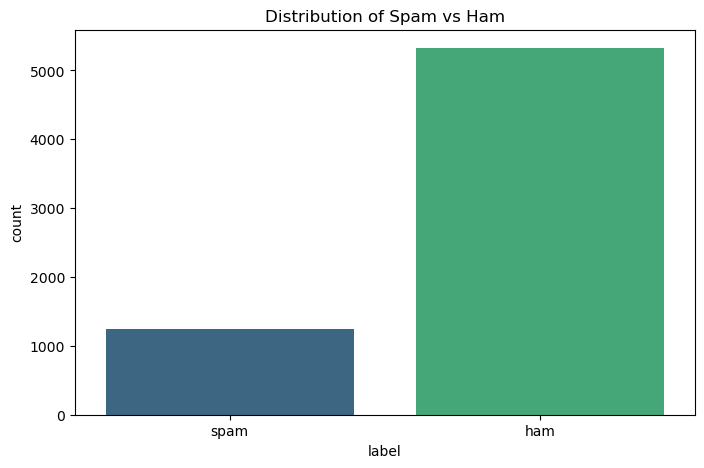

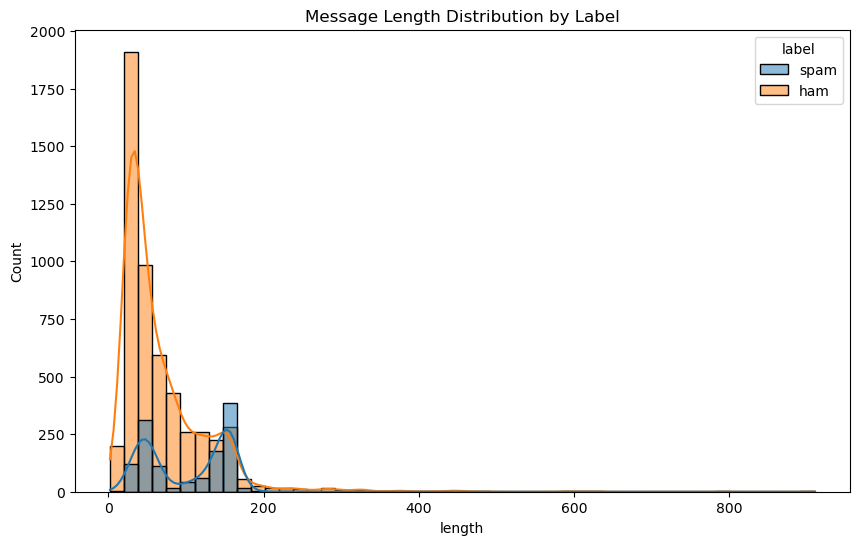

In [71]:
df = pd.read_csv("extended_spam_dataset.csv")
if len(df.columns) >= 2:
    df = df.iloc[:, :2]
    df.columns = ["label", "text"]

# Basic Info
print("Shape:", df.shape)
display(df.head())


# Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Spam vs Ham')
plt.show()

# Message Length Analysis
df['length'] = df['text'].apply(lambda x: len(str(x)))
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution by Label')
plt.show()

In [72]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df['label'].value_counts()


label
0    5325
1    1247
Name: count, dtype: int64

In [42]:
print(f"Initial row count: {len(df)}")
print(f"Number of duplicates: {df.duplicated().sum()}")

Initial row count: 6572
Number of duplicates: 1395


In [43]:
df_cleaned = df.drop_duplicates()
df_text_cleaned = df.drop_duplicates(subset=['text'], keep='first')
print(f"Cleaned row count: {len(df_text_cleaned)}")

Cleaned row count: 5177


In [63]:
counts = df_cleaned['label'].value_counts()

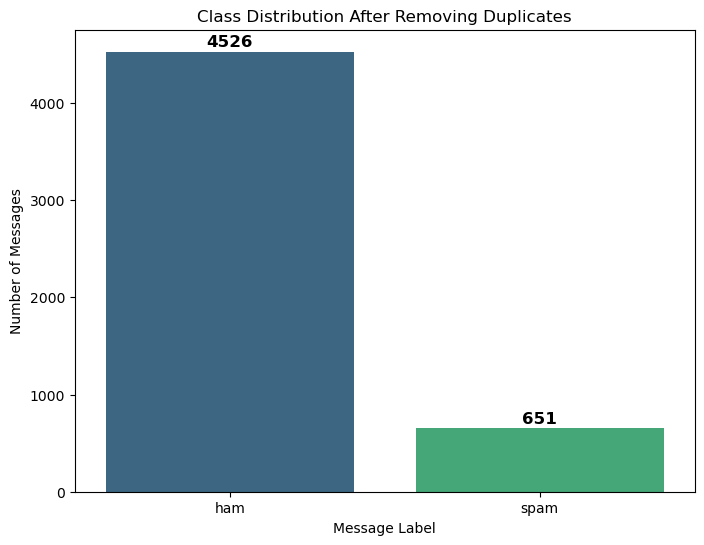

Cleaned Class Distribution:
label
ham     4526
spam     651
Name: count, dtype: int64


In [64]:
plt.figure(figsize=(8, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')

# Adding titles and labels
plt.title('Class Distribution After Removing Duplicates')
plt.xlabel('Message Label')
plt.ylabel('Number of Messages')

# Adding the exact count numbers on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12, fontweight='bold')

plt.show()

# Print the numerical summary
print("Cleaned Class Distribution:")
print(counts)

In [68]:
print("Train distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Train distribution:
label
ham     3625
spam     516
Name: count, dtype: int64

Test distribution:
label
ham     901
spam    135
Name: count, dtype: int64


In [62]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
print("already do")

already do


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [69]:
from nltk.corpus import stopwords

# Ensure stopwords are available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# English stopwords
english_stopwords = set(stopwords.words('english'))

#Somali stopwords (custom – can be expanded carefully)
somali_stopwords = {
    "iyo", "waa", "in", "ka", "ku", "si", "ayaa", "ma", "haa", "leh", "loo",
    "la", "u", "wax", "badan", "ahay", "karo", "mid", "kuma", "wuu", "waxa"
}

# Combine stopwords
all_stopwords = english_stopwords.union(somali_stopwords)

def clean_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 3. Tokenize (simple split)
    words = text.split()
    
    # 4. Remove English + Somali stopwords
    words = [word for word in words if word not in all_stopwords]
    
    # 5. Join words back to text
    return " ".join(words)

print("save wye")

save wye


In [45]:
df = pd.read_csv("extended_spam_dataset.csv").drop_duplicates(subset=['text']) 
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Lowercasing [cite: 13]
    text = str(text).lower()
    # Noise Removal (Punctuation/Special Characters) [cite: 16]
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization (Split into words) [cite: 12]
    words = text.split()
    # Stop word removal & Lemmatization [cite: 14, 15]
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned_words)

df['cleaned_text'] = df['text'].apply(preprocess_text)
print(df[['text', 'cleaned_text']].head())

                                                text  \
0  22 days to kick off! For Euro2004 U will be ke...   
1  Dai what this da.. Can i send my resume to thi...   
2  Al he does is moan at me if n e thin goes wron...   
3                       Maanta waan mashquulsanahay.   
4                     I'm in class. Will holla later   

                                        cleaned_text  
0  day kick euro u kept date latest news result d...  
1                              dai da send resume id  
2  al moan n e thin go wrong faultal de argument ...  
3                        maanta waan mashquulsanahay  
4                               im class holla later  


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer 
tfidf = TfidfVectorizer(max_features=3000) 
X = tfidf.fit_transform(df['cleaned_text'])
y = df['label']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (5177, 3000)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("data is spliting")

data is spliting


In [48]:
# Model Training LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97       901
        spam       0.94      0.67      0.78       135

    accuracy                           0.95      1036
   macro avg       0.95      0.83      0.88      1036
weighted avg       0.95      0.95      0.95      1036



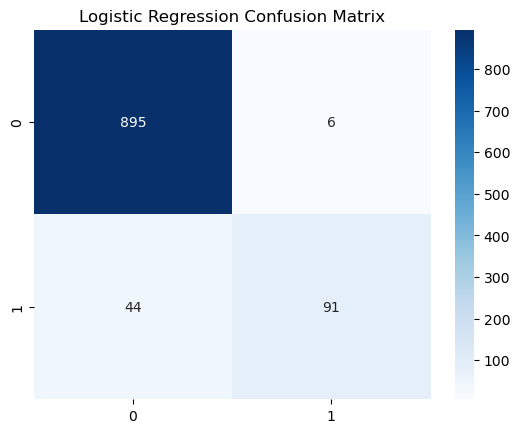

In [49]:
# Evaluation
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show() 

In [50]:
# Model Training
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       901
        spam       1.00      0.80      0.89       135

    accuracy                           0.97      1036
   macro avg       0.99      0.90      0.94      1036
weighted avg       0.97      0.97      0.97      1036



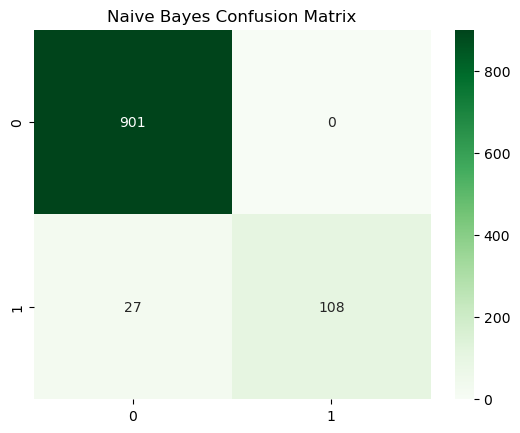

In [51]:
# Evaluation
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [52]:
# Model Training SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

SVM Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       901
        spam       0.97      0.86      0.91       135

    accuracy                           0.98      1036
   macro avg       0.98      0.93      0.95      1036
weighted avg       0.98      0.98      0.98      1036



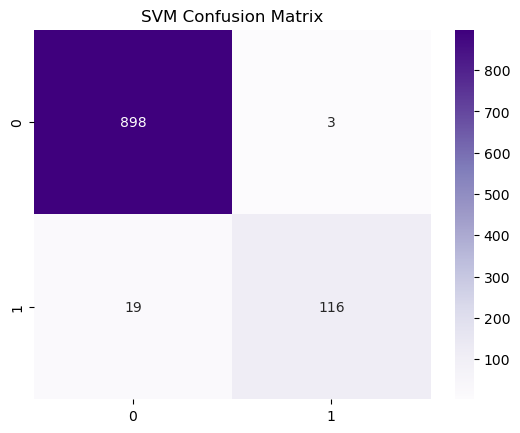

In [53]:
# Evaluation
y_pred_svm = svm_model.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples')
plt.title('SVM Confusion Matrix')
plt.show()

In [54]:
# Model Training RandomForest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=42)

Random Forest Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       901
        spam       1.00      0.61      0.76       135

    accuracy                           0.95      1036
   macro avg       0.97      0.81      0.87      1036
weighted avg       0.95      0.95      0.94      1036



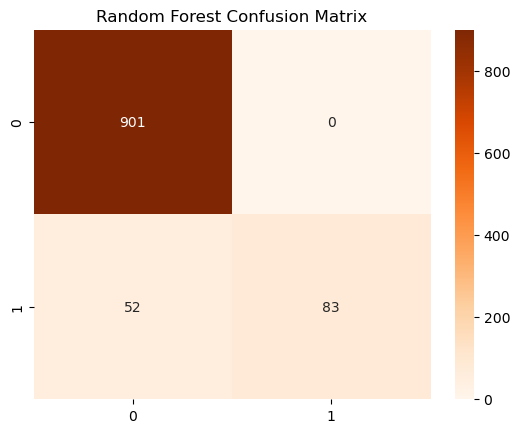

In [55]:
# Evaluation
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [56]:
# Model Training LightGBM Model
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 516, number of negative: 3625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.262481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6116
[LightGBM] [Info] Number of data points in the train set: 4141, number of used features: 334
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.124608 -> initscore=-1.949503
[LightGBM] [Info] Start training from score -1.949503


LGBMClassifier(random_state=42)

LightGBM Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       901
        spam       0.96      0.86      0.91       135

    accuracy                           0.98      1036
   macro avg       0.97      0.93      0.95      1036
weighted avg       0.98      0.98      0.98      1036



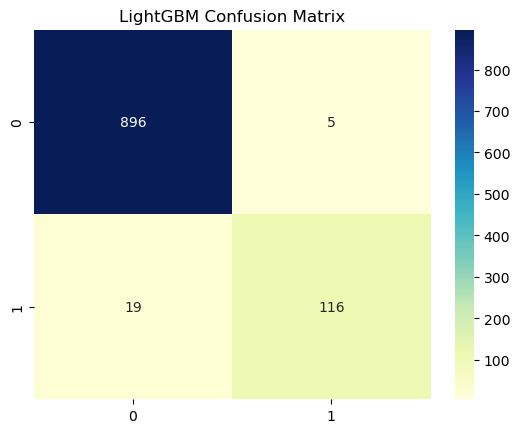

In [57]:
# Evaluation
y_pred_lgb = lgb_model.predict(X_test)
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='YlGnBu')
plt.title('LightGBM Confusion Matrix')
plt.show()

In [58]:
# Save the Vectorizer (Essential for transforming new text)
joblib.dump(tfidf, "vectorizer.pkl")

# Save each of your 5 models individually
joblib.dump(log_model, "logistic_regression_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(lgb_model, "lightgbm_model.pkl")

print("All models and the vectorizer have been saved successfully using joblib!")

All models and the vectorizer have been saved successfully using joblib!
